## EDA Process For Used Car Price Prediction

### Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Datasets
wv_df = pd.read_csv(r'D:\Hustle\Used-Car-Price-Prediction\Datasets\vw.csv')
audi_df = pd.read_csv(r'D:\Hustle\Used-Car-Price-Prediction\Datasets\audi.csv')

# Adding brand column to each datasets

wv_df['brand'] = 'Volkswagen'
audi_df['brand'] = 'Audi'

# Combining both Datasets into one dataset

df = pd.concat([wv_df, audi_df], ignore_index=True)

In [16]:
# getting know about the dataset

print(df.head())
print(df.info())
print(df.describe())
print(df.count())
print(df.isnull().sum())

    model  year  price transmission  mileage fuelType  tax   mpg  engineSize  \
0   T-Roc  2019  25000    Automatic    13904   Diesel  145  49.6         2.0   
1   T-Roc  2019  26883    Automatic     4562   Diesel  145  49.6         2.0   
2   T-Roc  2019  20000       Manual     7414   Diesel  145  50.4         2.0   
3   T-Roc  2019  33492    Automatic     4825   Petrol  145  32.5         2.0   
4   T-Roc  2019  22900    Semi-Auto     6500   Petrol  150  39.8         1.5   

        brand  
0  Volkswagen  
1  Volkswagen  
2  Volkswagen  
3  Volkswagen  
4  Volkswagen  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25825 entries, 0 to 25824
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         25825 non-null  object 
 1   year          25825 non-null  int64  
 2   price         25825 non-null  int64  
 3   transmission  25825 non-null  object 
 4   mileage       25825 non-null  int64  
 5   fuelType

## so no missing values, no redudency the dataset is clean as of i'm seeing ;)

# Distibution for price and mileage

Distribution is summarizing the data and drawn as an shape , that shape is called distribution

4 types of distribution:
    
    1. normal distribution ( Values cluster in the middle )
    2. right skewed (Mostly low, few very high )
    3. left skewed ( opposite to right, mostly high, few very low )
    4. uniform ( all values roughly equal )

Text(0.5, 1.0, 'Mileage Distribution')

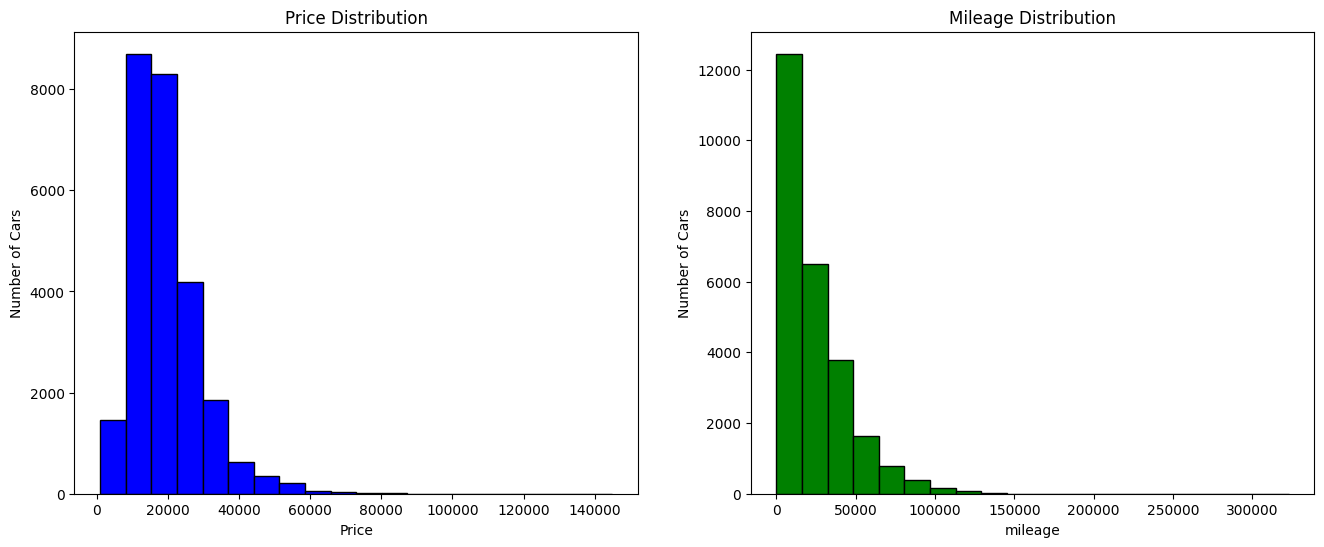

In [4]:
# plot histogram for price and mileage to find the distribution and outlier

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# plot 1 for price distribution
axes[0].hist(df['price'], color='blue', edgecolor='black', bins=20)
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Price Distribution')

# Plot 2 for mileage Distribution
axes[1].hist(df['mileage'], color='green', edgecolor='black', bins=20)
axes[1].set_xlabel('mileage')
axes[1].set_ylabel('Number of Cars')
axes[1].set_title('Mileage Distribution')

# Thoughts from the Distribution

## Price Distribution
    ~ most cars are cost between 10k - 15k 
    ~ very few cars are cost above 40k
    ~ so it is Right Skewed distribution

## Mileage Distribution 
    ~ most selled cars mileage are very low, so they are slightly new cars
    ~ this is also Right Skewed distribution

# Next Correlation

### Correlation means how two numbers move together, like when mileage goes up, does price go up or go down?


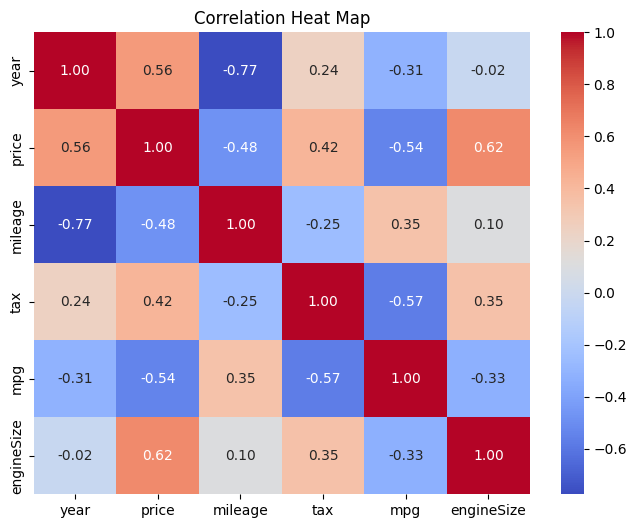

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plotting Heatmap
corr_mat = df.corr(numeric_only=True)
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt='.2f')
ax.set_title('Correlation Heat Map')
plt.show()

# Thoughts from the Heatmap

1. Car price is high when Engine size is high   (0.62)
2. if the car is new (year) the price hikes     (0.56)
3. if mpg is low the car prices is low          (-0.54)
4. more miles (mileage) lower cost              (-0.48)
5. high tax = high cost                         (0.42)

so the engine size (0.62) is the strong predictor followed by year (0.56) and mpg (-0.54)